In [2]:
import sys

In [3]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [4]:
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

2026-07-03 02:58:14.330267: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-03 02:58:14.331312: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-03 02:58:14.497427: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-03 02:58:14.867052: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-03 02:58:17.697813: W tensorflow/compiler/tf2

In [5]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [6]:
import pandas as pd
import h5py
import numpy as np

## Load training and test data, filter curves

In [7]:
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
fname = saveroot + "train_100k.parquet"
training_data = pd.read_parquet(fname)
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111021 entries, 0 to 111020
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   galaxy_id                   111021 non-null  float64
 1   ra                          111021 non-null  float64
 2   dec                         111021 non-null  float64
 3   sedid                       111021 non-null  int64  
 4   size                        111021 non-null  float64
 5   Ellipticity_1               111021 non-null  float64
 6   Ellipticity_2               111021 non-null  float64
 7   mag_u_lsst                  111021 non-null  float64
 8   mag_g_lsst                  111021 non-null  float64
 9   mag_r_lsst                  111021 non-null  float64
 10  mag_i_lsst                  111021 non-null  float64
 11  mag_z_lsst                  111021 non-null  float64
 12  mag_y_lsst                  111021 non-null  float64
 13  Roman_Y106    

In [8]:
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
fname = saveroot + "test_100k.parquet"
test_data = pd.read_parquet(fname)
#test_data.info()

In [9]:
# get the LSST and roman filter curves:
filter_root = "/global/homes/q/qhang/desc/rail_base/src/rail/examples_data/estimation_data/data/FILTER/"

wave = {
    "Y":106,
    "J":129,
    "H":158,
}
lsst_filter_curves = {}
roman_filter_curves = {}
for b in "ugrizy":
  lsst_filter_curves[b] = np.loadtxt(filter_root + f'DC2LSST_{b}.res')

for b in "YJH":
  roman_filter_curves[b] = np.loadtxt(filter_root + f'roman_{b}{wave[b]}.res')

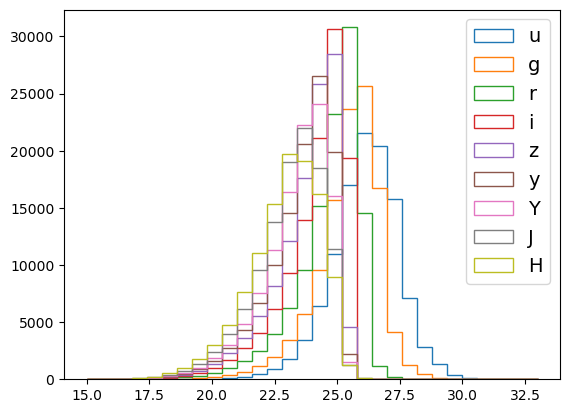

In [10]:
# check distribution of magnitude in each band:
for b in "ugrizy":
    cc = plt.hist(training_data[f'mag_{b}_lsst'], bins=30, range=[15,33], histtype='step', label=b)

for b in "YJH":
    cc = plt.hist(training_data[f'Roman_obs_{b}{wave[b]}'], bins=30, range=[15,33], histtype='step', label=b)
plt.legend()

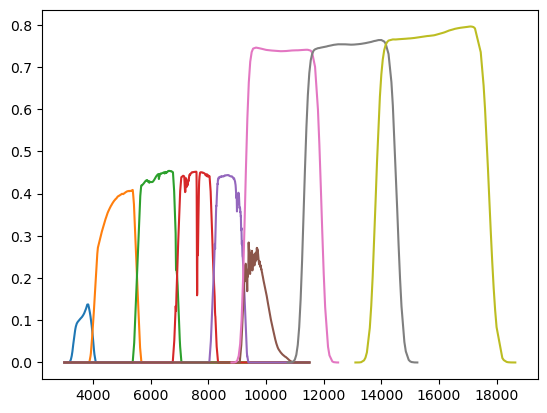

In [11]:
for b in "ugrizy":
  plt.plot(lsst_filter_curves[b][:,0], lsst_filter_curves[b][:,1])

for b in "YJH":
  plt.plot(roman_filter_curves[b][:,0], roman_filter_curves[b][:,1])

# predefined functions & variables

In [12]:
# define the wavelength grid
# to begin with, use blocks rather than filter curves
lambda_min = lsst_filter_curves['u'][:,0].min()
lambda_max = roman_filter_curves['H'][:,0].max()
print(lambda_min,lambda_max)

lambda_array = np.linspace(lambda_min,lambda_max,31)
# now let's conver filter curves to blocks: here let's also ignore the big Y band as it overlaps with the y band

3000.0 18650.0


In [13]:
def rebin_filter(bin_edges, counts, new_edges):
  new_counts = []
  for i in range(len(new_edges) - 1):
      lo, hi = new_edges[i], new_edges[i+1]
      total = 0.0
      for j, (b0, b1, c) in enumerate(
              zip(bin_edges[:-1], bin_edges[1:], counts)):
          overlap = max(0, min(hi, b1) - max(lo, b0))
          total  += c * overlap#/(b1 - b0)  # proportional share
      new_counts.append(total)
  return np.array(new_counts)

def get_bin_edges(centres):
    step = centres[1] - centres[0]          # uniform spacing
    inner_edges = (centres[:-1] + centres[1:]) / 2
    first_edge  = centres[0]  - step / 2
    last_edge   = centres[-1] + step / 2
    return np.concatenate([[first_edge], inner_edges, [last_edge]])

In [14]:
# now write a code to convert all galaxies in the training set into the desired data format:
# array of magnitude
# array of wavelength
# array of filter availability

def convert_data_format(df, lambda_array_cen):
    num_galaxies = len(df)
    num_wavelength_bins = len(lambda_array_cen)
    
    mags_data = np.zeros((num_galaxies, num_wavelength_bins))
    filter_availability_data = np.zeros((num_galaxies, num_wavelength_bins))
    
    for b in "ugrizy":
        ind = filter_blocks[b].astype(bool)
        mags_data[:, ind] = df[f'mag_{b}_lsst'].to_numpy()[:, None]
        filter_availability_data[:, ind] = 1
    
    for b in "JH":
        ind = filter_blocks[b].astype(bool)
        mags_data[:, ind] = df[f'Roman_obs_{b}{wave[b]}'].to_numpy()[:, None]
        filter_availability_data[:, ind] = 1
    
    # convert any nan to zero:
    ind_nan = np.isnan(mags_data)
    mags_data[ind_nan] = 0
    filter_availability_data[ind_nan] = 0

    wave_labels = np.arange(num_wavelength_bins)
    # normalize this
    wave_labels = wave_labels/wave_labels[-1]
    
    lambda_labels = np.outer(np.ones(num_galaxies), wave_labels)
    
    transformed_df = [mags_data, lambda_labels, filter_availability_data]
    transformed_df = np.stack(transformed_df, axis=-1)
    
    return transformed_df

In [15]:
#Functions to plot: bias, sigma, outlier fraction:
#Functions to produce these quantities as functin of mag
#from astropy.stats import biweight_location, biweight_scale
from scipy.stats import sigmaclip

def get_biweight_mean_sigma_outlier(subset, nclip= 3, abs_out_thresh=0.2):
    subset_clip, _, _ = sigmaclip(subset, low=3, high=3)
    for _j in range(nclip):
        subset_clip, _, _ = sigmaclip(subset_clip, low=3, high=3)

    #mean = biweight_location(subset_clip)
    #std = biweight_scale(subset_clip)
    mean = np.mean(subset_clip)
    std = np.std(subset_clip)
    #outlier_rate = np.sum(np.abs(subset) > 3 * biweight_scale(subset_clip)) / len(
    #    subset
    #)
    outlier_rate = np.sum(np.abs(subset) > 3 * np.std(subset_clip)) / len(
        subset
    )
    abs_outlier_rate = np.sum(np.abs(subset) > abs_out_thresh) / len(
        subset
    )

    return (
        mean,
        std / np.sqrt(len(subset_clip)),
        std,
        outlier_rate,
        abs_outlier_rate,
    )

In [16]:
import pickle

def get_all_stats(y_train, y_pred, imag_data, save=True, saveroot="", redshift_bins = np.linspace(0,2.5,11), imag_bins = np.linspace(18, 25.5,11)):
    Y = y_train.to_numpy()
    Y2 = y_pred.flatten()
    dz = (Y2 - Y)/(1+Y)
    stats = get_biweight_mean_sigma_outlier(dz, nclip= 3, abs_out_thresh=0.2)

    # split in terms of i-mags and redshifts
    redshift_stats = []
    imag_stats = []
    for i in range(10):
        ind= (Y > redshift_bins[i]) & (Y < redshift_bins[i+1])
        redshift_stats.append(get_biweight_mean_sigma_outlier(dz[ind]))
        ind= (imag_data > imag_bins[i]) & (imag_data < imag_bins[i+1])
        imag_stats.append(get_biweight_mean_sigma_outlier(dz[ind]))

    if save == True:
        with open(saveroot, "wb") as f:
            pickle.dump([stats, redshift_stats, imag_stats], f)

    return stats, redshift_stats, imag_stats

def read_stats(fname):
    with open(fname, "rb") as f:
        data = pickle.load(f)
    stats, redshift_stats, imag_stats = data
    return stats, redshift_stats, imag_stats

In [17]:
def plot_stats(stats, redshift_stats, imag_stats, y_train, y_pred, redshift_bins, imag_bins, i_mag_data):

    Y = y_train.to_numpy()
    Y2 = y_pred.flatten()
    dz = (Y2 - Y)/(1+Y)

    fig,axarr=plt.subplots(1,figsize=(8,8))

    plt.scatter(y_train, y_pred, s=0.1, color='k')
    plt.plot([0,2.5],[0,2.5],'r-')
    plt.ylabel('predicted redshift')
    plt.xlabel('truth redshift')
    plt.xlim([0,2.5])
    plt.ylim([0,2.5])
    
    mean, _mean_err, std, outlier_rate, abs_outlier_rate = stats
    mean, std, outlier_rate, abs_outlier_rate = (
                round(mean, 4),
                round(std, 4),
                round(outlier_rate, 4),
                round(abs_outlier_rate, 4),
            )
    
    plt.plot([0,2.5],[0- 3 * std, 2.5-3*std], 'r--')
    plt.plot([0,2.5],[0+ 3 * std, 2.5+3*std], 'r--')
    
    abs_out_thresh=0.2
    label=rf"$\Delta z = {mean} $" + "\n"  + rf"$\sigma z = {std} $"  + "\n"  + rf"outlier rate (>3$\sigma$) = {outlier_rate}"  + "\n" + f"outlier rate (>{abs_out_thresh}) = {abs_outlier_rate}"
    
    plt.text(0.1,1.5, label, fontsize=14)

    fig,axarr=plt.subplots(2,figsize=(8,8),sharex=True)

    N_bin = len(redshift_bins) - 1

    plt.sca(axarr[0])
    mean = np.zeros(N_bin)
    _mean_err = np.zeros(N_bin)
    std = np.zeros(N_bin)
    outlier_rate = np.zeros(N_bin)
    abs_outlier = np.zeros(N_bin)
    for i in range(N_bin):
      mean[i], _mean_err[i], std[i], outlier_rate[i], abs_outlier[i] = redshift_stats[i]
    
    plt.plot((redshift_bins[1:] + redshift_bins[:-1])/2, mean, '-',label="bias")
    plt.plot((redshift_bins[1:] + redshift_bins[:-1])/2, std, '-',label="$\sigma_z$")
    plt.plot((redshift_bins[1:] + redshift_bins[:-1])/2, outlier_rate, '-',label="outlier rate")
    plt.legend()
    plt.ylabel("statistics")
    
    plt.sca(axarr[1])
    plt.scatter(Y, dz, s=0.1, color='k')
    plt.xlabel("redshifts")
    plt.ylabel("$(z_{pred} - z_{true})/(1 + z_{true})$")
    
    plt.subplots_adjust(hspace=0)

    fig,axarr=plt.subplots(2,figsize=(8,8),sharex=True)

    N_bin = len(imag_bins) - 1

    plt.sca(axarr[0])
    mean = np.zeros(N_bin)
    _mean_err = np.zeros(N_bin)
    std = np.zeros(N_bin)
    outlier_rate = np.zeros(N_bin)
    abs_outlier = np.zeros(N_bin)
    for i in range(N_bin):
        mean[i], _mean_err[i], std[i], outlier_rate[i], abs_outlier[i] = imag_stats[i]
    
    plt.plot((imag_bins[1:] + imag_bins[:-1])/2, mean, '-',label="bias")
    plt.plot((imag_bins[1:] + imag_bins[:-1])/2, std, '-',label="$\sigma_z$")
    plt.plot((imag_bins[1:] + imag_bins[:-1])/2, outlier_rate, '-',label="outlier rate")
    plt.legend()
    plt.ylabel("statistics")
    
    plt.sca(axarr[1])
    plt.scatter(i_mag_data, dz, s=0.1, color='k')
    plt.xlabel("i magnitude")
    plt.ylabel("$(z_{pred} - z_{true})/(1 + z_{true})$")
    
    plt.subplots_adjust(hspace=0)

In [18]:
def stats_to_markdown(stats1_input, stats2_input, labels=("Mean", "Mean err", "Std", "Outlier rate", "Abs outlier rate"), skip_indices=(1,),
                     data_title=("Dataset 1", "Dataset 2")):
    # 0. Filter out skipped indices
    keep = [i for i in range(len(stats1_input)) if i not in skip_indices]
    stats1 = [stats1_input[i] for i in keep]
    stats2 = [stats2_input[i] for i in keep]
    labels = [labels[i] for i in keep]
    
    # 1. Fractional change vs dataset 1
    pct_change = [100 * (s2 - s1) / s1 if s1 != 0 else float('nan')
                  for s1, s2 in zip(stats1, stats2)]
    
    # 3. Build rows, rounded to 3 digits
    rows = []
    for label, s1, s2, pc in zip(labels, stats1, stats2, pct_change):
        rows.append(f"| {label} | {s1:.3g} | {s2:.3g} | {pc:.3g}% |")
    
    # 4. Assemble Markdown
    md = (
        f"| Statistic | {data_title[0]} | {data_title[1]} | % change |\n"
        "|---|---:|---:|---:|\n"
        + "\n".join(rows)
    )
    return md

In [19]:
def compare_binned_stats(redshift_bins, imag_bins, redshift_stats1, imag_stats1, redshift_stats2, imag_stats2):
    fig,axarr=plt.subplots(1, 2,figsize=(10,4))

    xlabels=["redshifts", "i magnitude"]

    for j, bins, stats1, stats2 in zip([0,1], [redshift_bins, imag_bins], 
                                      [redshift_stats1, imag_stats1], [redshift_stats2, imag_stats2]):
        plt.sca(axarr[j])
        N_bin = len(bins) - 1
        xx = (bins[1:] + bins[:-1])/2
        
        mean1 = np.zeros(N_bin)
        std1 = np.zeros(N_bin)
        outlier_rate1 = np.zeros(N_bin)
        for i in range(N_bin):
          mean1[i], _, std1[i], outlier_rate1[i], _ = stats1[i]
    
    
        mean2 = np.zeros(N_bin)
        std2 = np.zeros(N_bin)
        outlier_rate2 = np.zeros(N_bin)
        for i in range(N_bin):
          mean2[i], _, std2[i], outlier_rate2[i], _ = stats2[i]
        
        plt.plot(xx, mean1, '-',label="bias", color="C0")
        plt.plot(xx, std1, '-',label="$\sigma_z$", color="C1")
        plt.plot(xx, outlier_rate1, '-',label="outlier rate", color="C2")

        plt.plot(xx, mean2, '--', color="C0")
        plt.plot(xx, std2, '--', color="C1")
        plt.plot(xx, outlier_rate2, '--', color="C2")
        plt.legend()
        plt.ylabel("statistics")
        plt.xlabel(xlabels[j])
        plt.grid()
    plt.tight_layout()

### Transform data, make X_train, Y_train, and test dataset, variants of this dataset

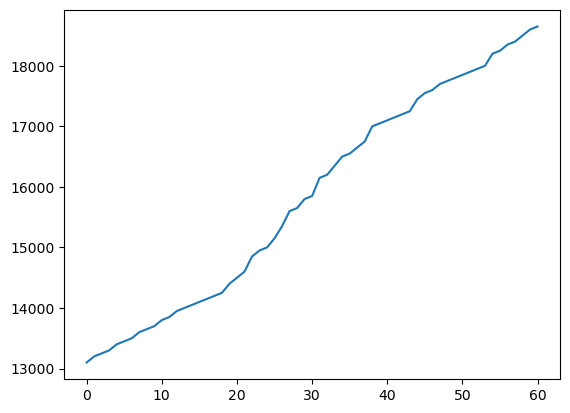

In [20]:
plt.plot(roman_filter_curves[b][:,0])

In [21]:
bin_edges = {}
for b in "ugrizyJH":
  if b not in "JH":
    bin_edges[b] = get_bin_edges(lsst_filter_curves[b][:,0])
  else:
    bin_edges[b] = get_bin_edges(roman_filter_curves[b][:,0])
new_edges = lambda_array

rebinned_filters={}
for b in "ugrizyJH":
  if b not in "JH":
    counts = lsst_filter_curves[b][:,1]
  else:
    counts = roman_filter_curves[b][:,1]
  rebinned_filters[b] = rebin_filter(bin_edges[b], counts, new_edges)

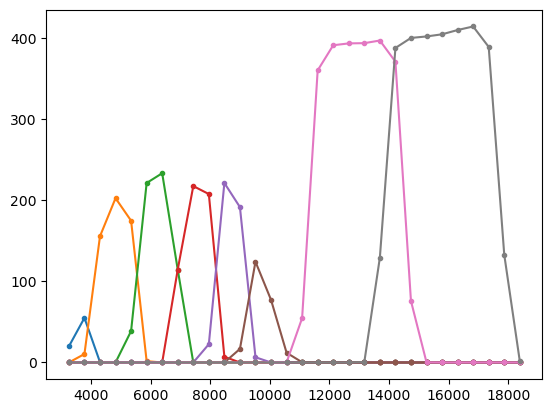

In [22]:
lambda_array_cen = (new_edges[1:] + new_edges[:-1])/2
dlambda = new_edges[1] - new_edges[0]
for b in "ugrizyJH":
  plt.plot(lambda_array_cen, rebinned_filters[b],'.-')

In [23]:
# further convert this to blocks:
# let's take 1 when the current filter value is > next filter
filter_blocks={}
bands = "ugrizyJH"
for i, b in enumerate("ugrizyJ"):
  if i>0:
    filter_blocks[b] = (rebinned_filters[b] >= rebinned_filters[bands[i+1]]) & (rebinned_filters[b] > rebinned_filters[bands[i-1]])
  else:
    filter_blocks[b] = (rebinned_filters[b] > rebinned_filters[bands[i+1]])
filter_blocks['H'] = (rebinned_filters['H'] > rebinned_filters['J']) & (rebinned_filters['H'] > rebinned_filters['y'])

Text(0, 0.5, 'filter')

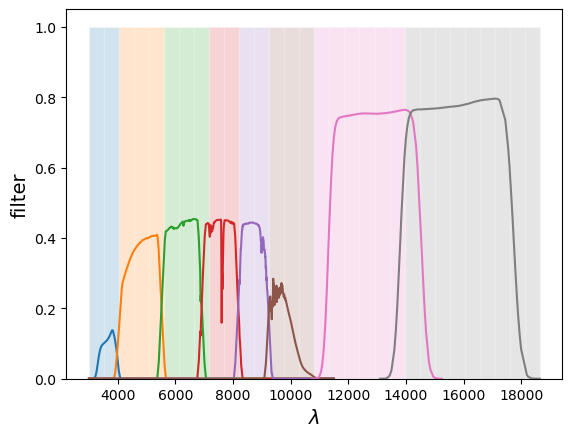

In [20]:
fig, ax = plt.subplots()
widths = np.diff(new_edges)
for i, b in enumerate("ugrizyJH"):
  ax.bar(lambda_array_cen , filter_blocks[b].astype(int), color=f'C{i}', width=widths, alpha=0.2,
         edgecolor='white')

for b in "ugrizy":
  plt.plot(lsst_filter_curves[b][:,0], lsst_filter_curves[b][:,1])

for b in "JH":
  plt.plot(roman_filter_curves[b][:,0], roman_filter_curves[b][:,1])
plt.xlabel(r'$\lambda$')
plt.ylabel('filter')

In [26]:
training_data_transformed = convert_data_format(training_data, lambda_array_cen)
print(training_data_transformed.shape)

(111021, 30, 3)


In [24]:
from sklearn.model_selection import train_test_split

In [27]:
# now split training and validation set:
Y = training_data['redshift']
X = np.copy(training_data_transformed)
indices = np.arange(len(Y))

X_train, X_val, Y_train, Y_val, idx_train, idx_val = train_test_split(
    X, Y, indices,
    test_size=0.2,
    random_state=42    # for reproducibility
)

Y_mean, Y_std = Y.mean(), Y.std()
max_mag = training_data_transformed[:,:,0].max()

print(Y_mean, Y_std, max_mag)

Y_train_norm = (Y_train - Y_mean) / Y_std
X_train[:,:,0] = X_train[:,:,0]/max_mag

Y_val_norm = (Y_val - Y_mean) / Y_std
X_val[:,:,0] = X_val[:,:,0]/max_mag

0.8334133850709813 0.44877273440870596 32.524588453356856


In [28]:
print(X_train.shape, Y_train.shape, X_val.shape, Y_val.shape)
print(idx_train[:5])

(88816, 30, 3) (88816,) (22205, 30, 3) (22205,)
[37255 37221 19040 29807 78691]


Text(0.5, 1.0, 'Example data vector')

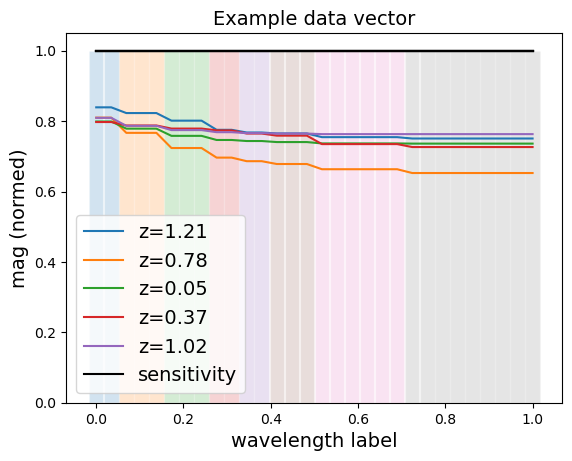

In [29]:
delta_wave = 1/len(lambda_array_cen)
for i, b in enumerate("ugrizyJH"):
  plt.bar(X_train[i,:,1] , filter_blocks[b].astype(int), color=f'C{i}', width=delta_wave, alpha=0.2,
         edgecolor='white')
for i in range(5):
  z = training_data['redshift'][i]
  plt.plot(X_train[i,:,1], X_train[i,:,0], label=f"z={round(z,2)}")
  plt.plot(X_train[i,:,1], X_train[i,:,2], color='k')

plt.plot(X_train[i,:,1], X_train[i,:,2], color='k', label="sensitivity")
plt.ylabel("mag (normed)")
plt.xlabel("wavelength label")
plt.legend()
plt.title("Example data vector")

Number of objects at z>1.5:  10001


Text(0.5, 1.0, 'Example data vector ($z>1.5$)')

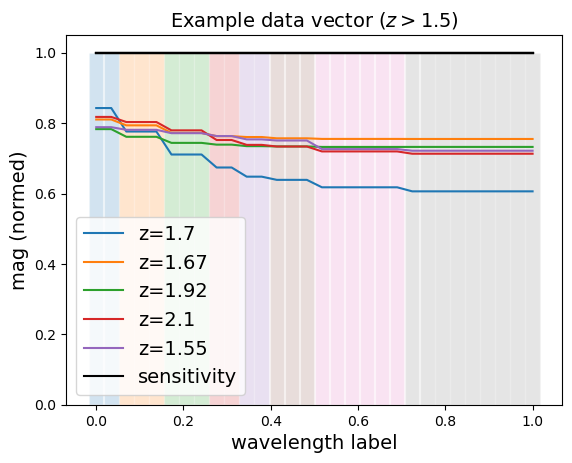

In [30]:
delta_wave = 1/len(lambda_array_cen)
for i, b in enumerate("ugrizyJH"):
  plt.bar(X_train[i,:,1] , filter_blocks[b].astype(int), color=f'C{i}', width=delta_wave, alpha=0.2,
         edgecolor='white')

ind = np.where(training_data['redshift'] > 1.5)[0]
print("Number of objects at z>1.5: ", len(ind))
for i in range(5):
    useind = ind[i]
    z = training_data['redshift'][useind]
    plt.plot(X_train[useind,:,1], X_train[useind,:,0], label=f"z={round(z,2)}")
    plt.plot(X_train[useind,:,1], X_train[useind,:,2], color='k')

plt.plot(X_train[i,:,1], X_train[i,:,2], color='k', label="sensitivity")
plt.ylabel("mag (normed)")
plt.xlabel("wavelength label")
plt.legend()
plt.title("Example data vector ($z>1.5$)")

In [31]:
# now also make test data:
test_data_transformed = convert_data_format(test_data, lambda_array_cen)

Y_test = test_data['redshift']
Y_test_norm = (Y_test - Y_mean) / Y_std # use same mean and std
X_test = np.copy(test_data_transformed)
X_test[:,:,0] = X_test[:,:,0]/max_mag # use same max mag

#### Missing NIR data

We will fix the normalization parameters as the previous case

In [32]:
#training
Ndata = Y_train.shape[0]
N_noNIR = int(0.3*Ndata)
ind1 = np.random.choice(np.arange(Ndata), size=N_noNIR, replace=False)
X_train_missing = np.copy(X_train)
X_train_missing[ind1, 15:, 0] = 0 # mag
X_train_missing[ind1, 15:, 2] = 0 # sensitivity

# validation:
Ndata = Y_val.shape[0]
N_noNIR = int(0.3*Ndata)
ind2 = np.random.choice(np.arange(Ndata), size=N_noNIR, replace=False)
X_val_missing = np.copy(X_val)

X_val_missing[ind2, 15:, 0] = 0 # mag
X_val_missing[ind2, 15:, 2] = 0 # sensitivity

In [33]:
Y_train.to_numpy()

array([0.78419153, 0.58255556, 0.59344688, ..., 1.08698067, 0.41075274,
       1.24327365])

In [34]:
# augmented datasets:
X_train_missing_agumented = np.concatenate([X_train, X_train_missing[ind1,:,:]], axis=0)
Y_train_missing_augmented = np.concatenate([Y_train_norm, Y_train_norm.to_numpy()[ind1]])
print(X_train_missing_agumented.shape, Y_train_missing_augmented.shape)

(115460, 30, 3) (115460,)


Text(0.5, 1.0, 'Example data vector (missing NIR)')

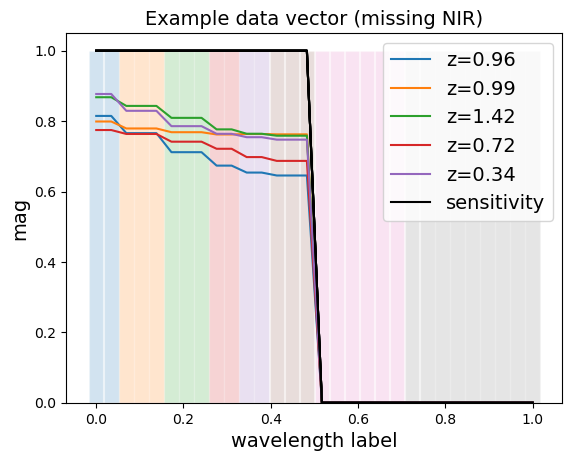

In [35]:
# check data with missing bands:
delta_wave = 1/len(lambda_array_cen)
for i, b in enumerate("ugrizyJH"):
  plt.bar(X_train_missing[i,:,1] , filter_blocks[b].astype(int), color=f'C{i}', width=delta_wave, alpha=0.2,
         edgecolor='white')
for i in range(5):
    useind = ind1[i]
    z = training_data['redshift'][useind]
    plt.plot(X_train_missing[useind,:,1], X_train_missing[useind,:,0], label=f"z={round(z,2)}")
    plt.plot(X_train_missing[useind,:,1], X_train_missing[useind,:,2], color='k')

plt.plot(X_train_missing[useind,:,1], X_train_missing[useind,:,2], color='k', label="sensitivity")
plt.ylabel("mag")
plt.xlabel("wavelength label")
plt.legend()
plt.title("Example data vector (missing NIR)")

In [36]:
Ndata = Y_test.shape[0]
N_noNIR = int(0.3*Ndata)
ind = np.random.choice(np.arange(Ndata), size=N_noNIR, replace=False)
X_test_missing = np.copy(X_test)

X_test_missing[ind, 15:, 0] = 0 # mag
X_test_missing[ind, 15:, 2] = 0 # sensitivity

# training model

In [144]:
# here code up a CNN to with a 1D filter:
from tensorflow.keras import layers, models, callbacks

tf.keras.backend.clear_session()

def build_model(input_shape):
    model = models.Sequential([
        layers.Conv1D(32,  kernel_size=3, activation='relu',
                      padding='same', input_shape=input_shape),
        layers.MaxPooling1D(),
        layers.Conv1D(64,  kernel_size=3, activation='relu',
                      padding='same'),
        layers.MaxPooling1D(),
        layers.Conv1D(128, kernel_size=3, activation='relu',
                      padding='same'),
        layers.MaxPooling1D(),
        layers.Conv1D(256, kernel_size=3, activation='relu',
                      padding='same'),
        #layers.MaxPooling1D(),
        layers.Conv1D(512, kernel_size=3, activation='relu',
                      padding='same'),
        layers.Conv1D(512, kernel_size=3, activation='relu',
                      padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1)
    ])
    return model

model = build_model(input_shape=(30, 3))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

# ── Callbacks ─────────────────────────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 30, 32)            320       
                                                                 
 max_pooling1d (MaxPooling1  (None, 15, 32)            0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 15, 64)            6208      
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 7, 64)             0         
 g1D)                                                            
                                                                 
 conv1d_2 (Conv1D)           (None, 7, 128)            24704     
                                                                 
 max_pooling1d_2 (MaxPoolin  (None, 3, 128)            0

In [145]:
# ── Train ─────────────────────────────────────────────────────────────────────
history = model.fit(
    X_train, Y_train_norm,
    #validation_split=0.2,
    validation_data=(X_val, Y_val_norm), 
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
347/347 [==============================] - 14s 25ms/step - loss: 0.5933 - mae: 0.5782 - val_loss: 0.1397 - val_mae: 0.2778 - lr: 0.0010
Epoch 2/100
347/347 [==============================] - 4s 13ms/step - loss: 0.1764 - mae: 0.3099 - val_loss: 0.1258 - val_mae: 0.2645 - lr: 0.0010
Epoch 3/100
347/347 [==============================] - 4s 13ms/step - loss: 0.1148 - mae: 0.2420 - val_loss: 0.0465 - val_mae: 0.1353 - lr: 0.0010
Epoch 4/100
347/347 [==============================] - 4s 13ms/step - loss: 0.1024 - mae: 0.2256 - val_loss: 0.0414 - val_mae: 0.1281 - lr: 0.0010
Epoch 5/100
347/347 [==============================] - 5s 13ms/step - loss: 0.0889 - mae: 0.2077 - val_loss: 0.0507 - val_mae: 0.1665 - lr: 0.0010
Epoch 6/100
347/347 [==============================] - 5s 13ms/step - loss: 0.0819 - mae: 0.1981 - val_loss: 0.0378 - val_mae: 0.1186 - lr: 0.0010
Epoch 7/100
347/347 [==============================] - 5s 13ms/step - loss: 0.0810 - mae: 0.1952 - val_loss: 0.0392 -

<Axes: xlabel='Epoch'>

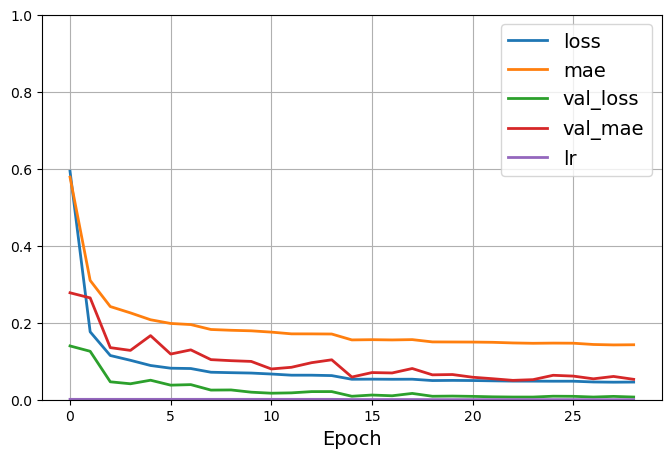

In [146]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5),
    linewidth=2,
    grid=True,
    xlabel='Epoch',
    ylim=(0,1),
)

In [147]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/cardinal/models/"
model.save(root + 'basic_CNN.model.6lyaers.keras')

# Save normalisation parameters alongside it
np.save(root + 'basic_CNN.norm_params.6lyaers.npy', {
    'Y_mean': Y_mean, 'Y_std': Y_std, "X_max": max_mag, 
})

In [148]:
root = "/pscratch/sd/q/qhang/cnnpz/cardinal/models/"
model = tf.keras.models.load_model(root + 'basic_CNN.model.6lyaers.keras')
params = np.load(root + 'basic_CNN.norm_params.6lyaers.npy',
                 allow_pickle=True).item()
Y_mean, Y_std, X_max = params['Y_mean'], params['Y_std'], params['X_max']

In [149]:
Y_pred_norm = model.predict(X_train)
Y_pred_train      = Y_pred_norm * Y_std + Y_mean

Y_pred_norm = model.predict(X_test)
Y_pred_test      = Y_pred_norm * Y_std + Y_mean

3470/3470 [==============================] - 18s 5ms/step


In [150]:
len(X_train), len(X_test)

(88816, 111022)

In [151]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
root = "/pscratch/sd/q/qhang/cnnpz/cardinal/models/"
saveroot = root + "basic_CNN.stats-train.6lyaers.pkl"
stats1, redshift_stats1, imag_stats1 = get_all_stats(Y_train, Y_pred_train, training_data['mag_i_lsst'][idx_train], save=True, saveroot=saveroot, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

saveroot = root + "basic_CNN.stats-test.6lyaers.pkl"
stats2, redshift_stats2, imag_stats2 = get_all_stats(Y_test, Y_pred_test, test_data['mag_i_lsst'], save=True, saveroot=saveroot, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

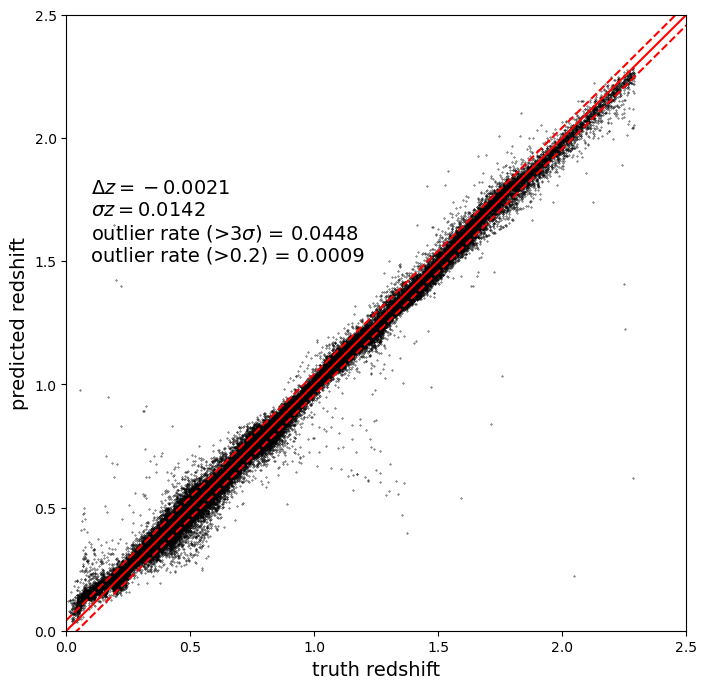

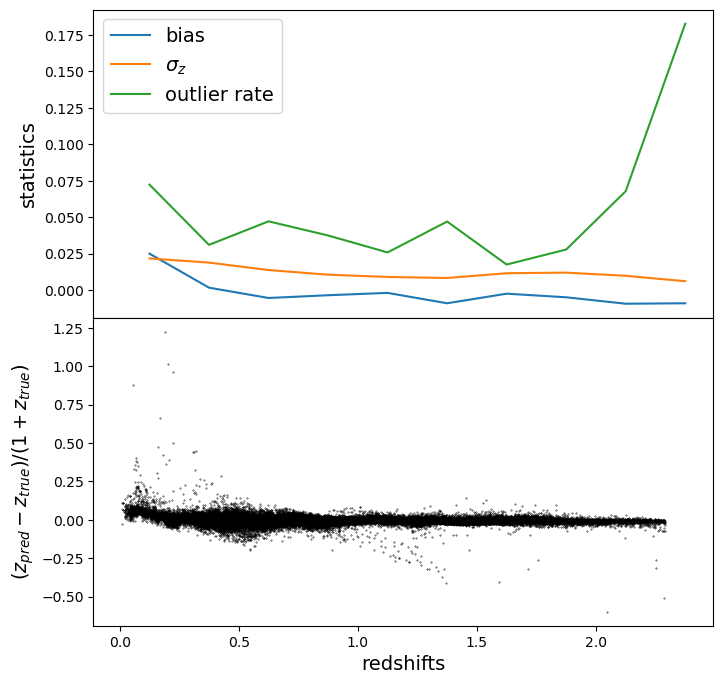

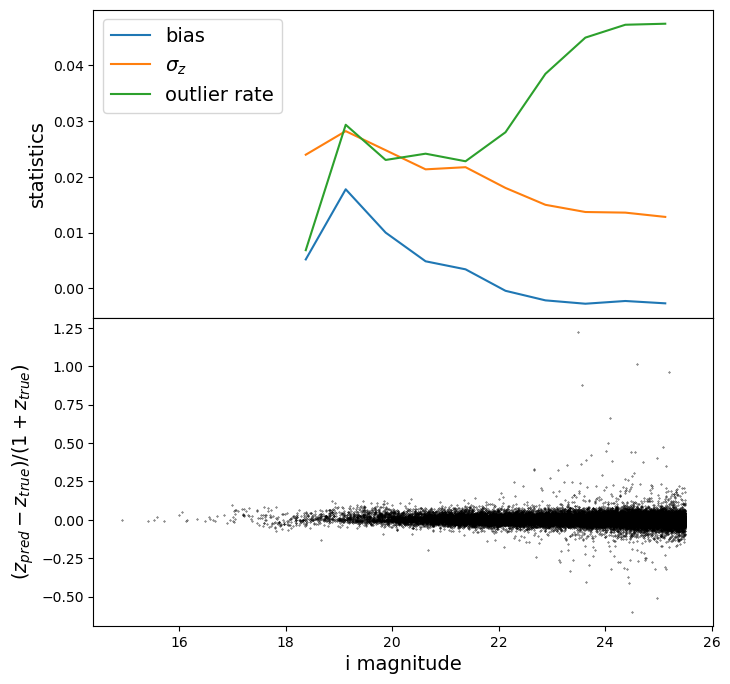

In [152]:
plot_stats(stats1, redshift_stats1, imag_stats1, Y_train, Y_pred_train, redshift_bins, imag_bins, training_data['mag_i_lsst'][idx_train])

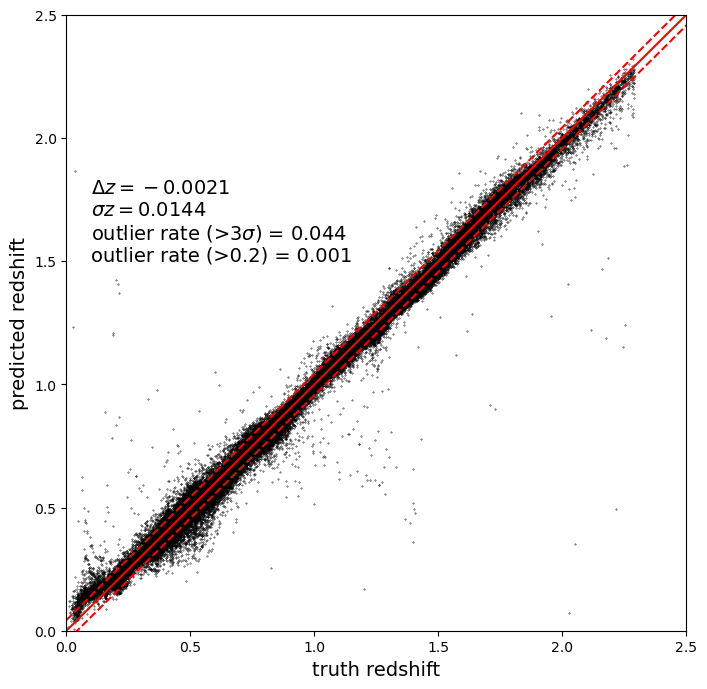

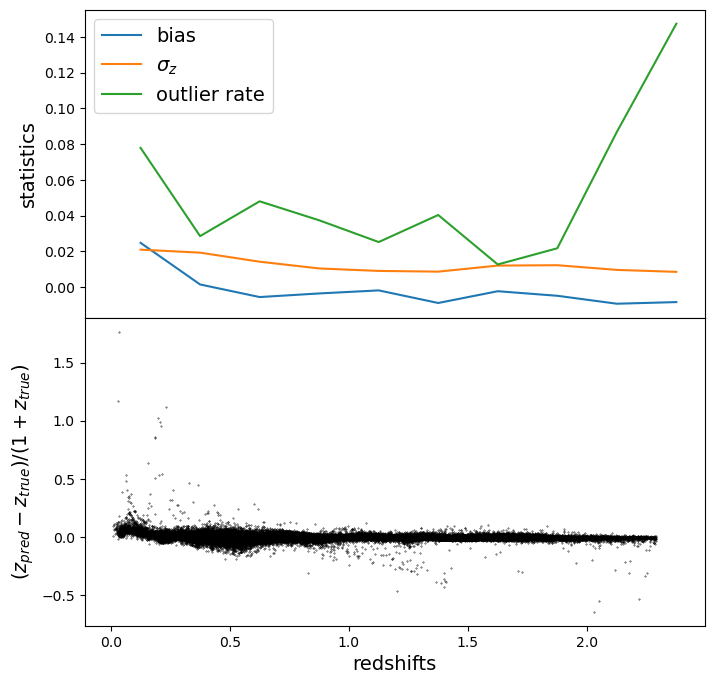

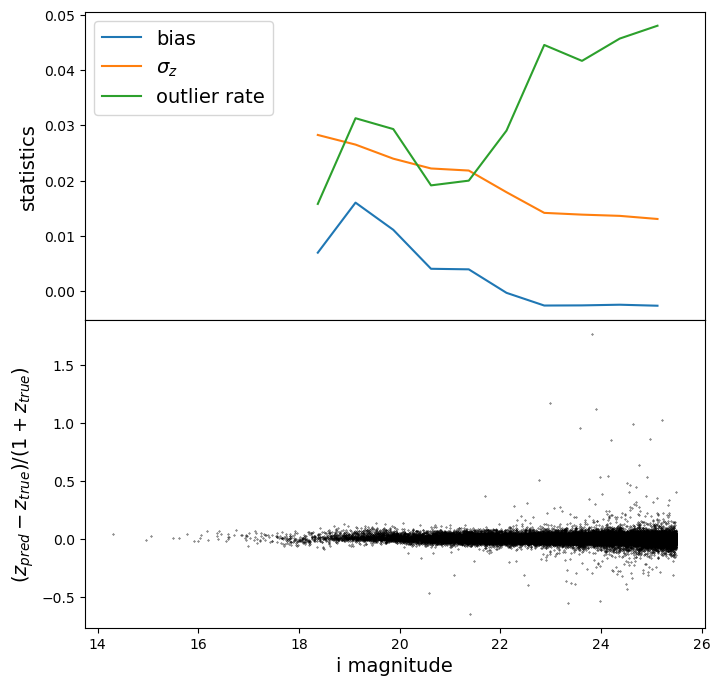

In [153]:
#training
plot_stats(stats2, redshift_stats2, imag_stats2, Y_test, Y_pred_test, redshift_bins, imag_bins, test_data['mag_i_lsst'])

# Missing NIR bands

For a fraction of the training data, remove the NIR bands

In [187]:
# here code up a CNN to with a 1D filter:
from tensorflow.keras import layers, models, callbacks

tf.keras.backend.clear_session()

def build_model(input_shape):
    model = models.Sequential([
        layers.Conv1D(32,  kernel_size=3, activation='relu',
                      padding='same', input_shape=input_shape),
        layers.MaxPooling1D(),
        layers.Conv1D(64,  kernel_size=3, activation='relu',
                      padding='same'),
        layers.MaxPooling1D(),
        layers.Conv1D(128, kernel_size=3, activation='relu',
                      padding='same'),
        layers.MaxPooling1D(),
        layers.Conv1D(256, kernel_size=3, activation='relu',
                      padding='same'),
        layers.MaxPooling1D(),
        layers.Conv1D(512, kernel_size=3, activation='relu',
                      padding='same'),
        #layers.Conv1D(512, kernel_size=3, activation='relu',
        #              padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1)
    ])
    return model

model = build_model(input_shape=(30, 3))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

# ── Callbacks ─────────────────────────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 30, 32)            320       
                                                                 
 max_pooling1d (MaxPooling1  (None, 15, 32)            0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 15, 64)            6208      
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 7, 64)             0         
 g1D)                                                            
                                                                 
 conv1d_2 (Conv1D)           (None, 7, 128)            24704     
                                                                 
 max_pooling1d_2 (MaxPoolin  (None, 3, 128)            0

In [188]:
# ── Train ─────────────────────────────────────────────────────────────────────
history = model.fit(
    X_train_missing, Y_train_norm,
    validation_data=(X_val_missing, Y_val_norm),
    #validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
347/347 [==============================] - 6s 12ms/step - loss: 0.5837 - mae: 0.5685 - val_loss: 0.1978 - val_mae: 0.3033 - lr: 0.0010
Epoch 2/100
347/347 [==============================] - 4s 11ms/step - loss: 0.1911 - mae: 0.3068 - val_loss: 0.1252 - val_mae: 0.2437 - lr: 0.0010
Epoch 3/100
347/347 [==============================] - 4s 11ms/step - loss: 0.1454 - mae: 0.2638 - val_loss: 0.0829 - val_mae: 0.1901 - lr: 0.0010
Epoch 4/100
347/347 [==============================] - 4s 11ms/step - loss: 0.1098 - mae: 0.2269 - val_loss: 0.0654 - val_mae: 0.1632 - lr: 0.0010
Epoch 5/100
347/347 [==============================] - 4s 11ms/step - loss: 0.0978 - mae: 0.2107 - val_loss: 0.0733 - val_mae: 0.1739 - lr: 0.0010
Epoch 6/100
347/347 [==============================] - 4s 11ms/step - loss: 0.0902 - mae: 0.2007 - val_loss: 0.0628 - val_mae: 0.1604 - lr: 0.0010
Epoch 7/100
347/347 [==============================] - 4s 12ms/step - loss: 0.0893 - mae: 0.2003 - val_loss: 0.0483 - 

<Axes: xlabel='Epoch'>

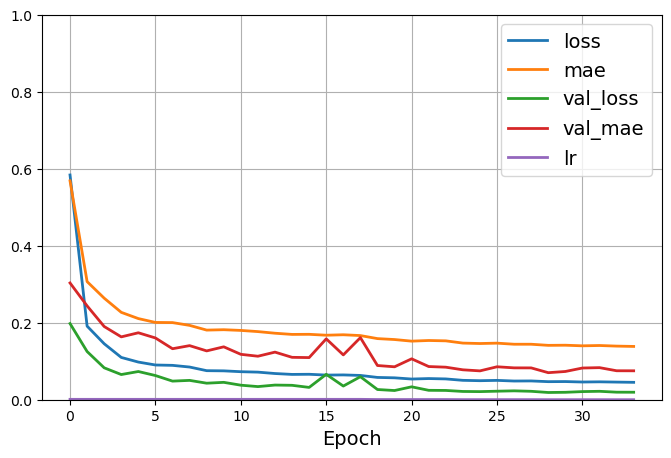

In [189]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5),
    linewidth=2,
    grid=True,
    xlabel='Epoch',
    ylim=(0,1),
)

In [190]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/cardinal/models/"
model.save(root + 'basic_CNN_missing_NIR_frac_0.3.model.5layers.keras')

# Save normalisation parameters alongside it
np.save(root + 'basic_CNN_missing_NIR_frac_0.3.norm_params.5layers.npy', {
    'Y_mean': Y_mean, 'Y_std': Y_std, 'X_max': max_mag,
})

In [37]:
# load model and params:
root = "/pscratch/sd/q/qhang/cnnpz/cardinal/models/"
model = tf.keras.models.load_model(root + 'basic_CNN_missing_NIR_frac_0.3.model.5layers.keras')
params = np.load(root + 'basic_CNN_missing_NIR_frac_0.3.norm_params.5layers.npy',
                 allow_pickle=True).item()
Y_mean, Y_std, X_max = params['Y_mean'], params['Y_std'], params['X_max']

2026-07-03 03:05:29.015800: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38479 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:c3:00.0, compute capability: 8.0


In [38]:
Y_pred_norm = model.predict(X_train_missing)
Y_pred_train      = Y_pred_norm * Y_std + Y_mean

Y_pred_norm = model.predict(X_test_missing)
Y_pred_test      = Y_pred_norm * Y_std + Y_mean

2026-07-03 03:05:36.464007: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8903


3470/3470 [==============================] - 5s 1ms/step


In [39]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
root = "/pscratch/sd/q/qhang/cnnpz/cardinal/models/"
saveroot = root + "basic_CNN_missing_NIR_frac_0.3.stats-train.5layers.pkl"
stats3, redshift_stats3, imag_stats3 = get_all_stats(Y_train, Y_pred_train, training_data['mag_i_lsst'][idx_train], save=True, saveroot=saveroot, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

saveroot = root + "basic_CNN_missing_NIR_frac_0.3.stats-test.5layers.pkl"
stats4, redshift_stats4, imag_stats4 = get_all_stats(Y_test, Y_pred_test, test_data['mag_i_lsst'], save=True, saveroot=saveroot, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

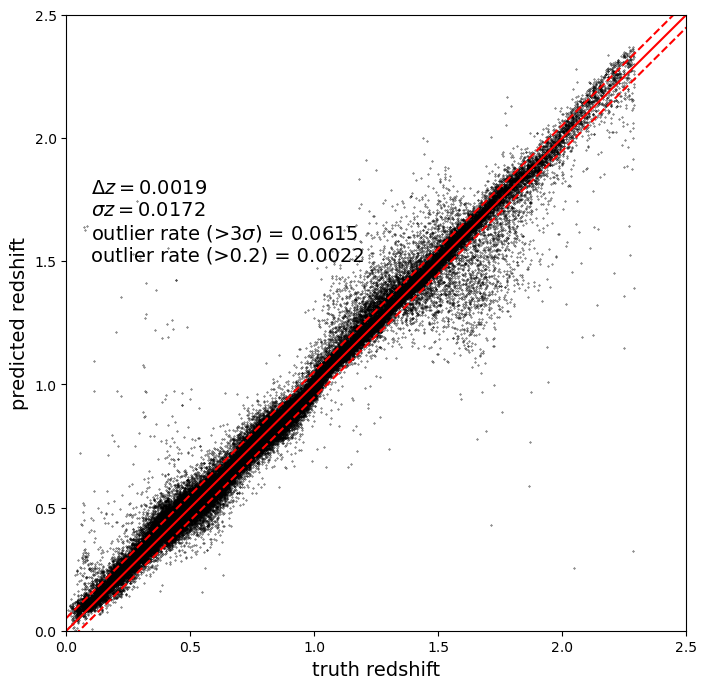

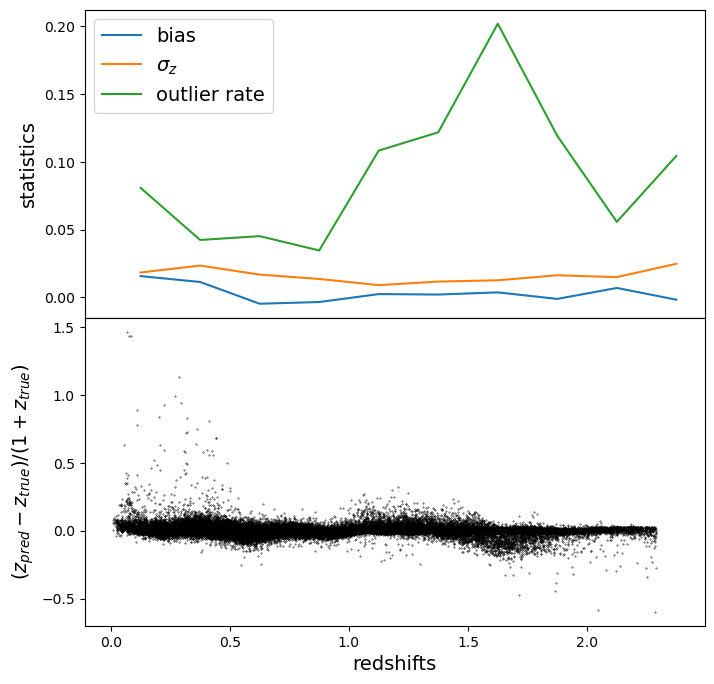

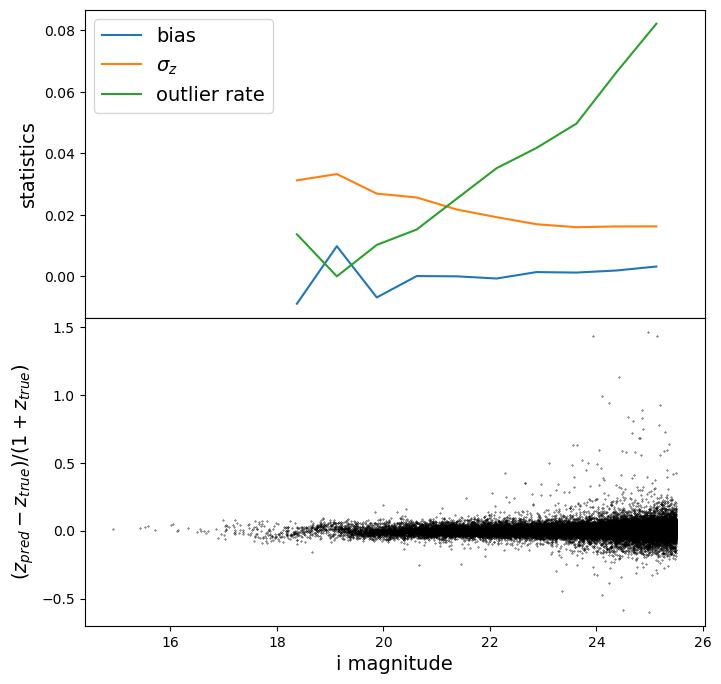

In [40]:
plot_stats(stats3, redshift_stats3, imag_stats3, Y_train, Y_pred_train, redshift_bins, imag_bins, training_data['mag_i_lsst'][idx_train])

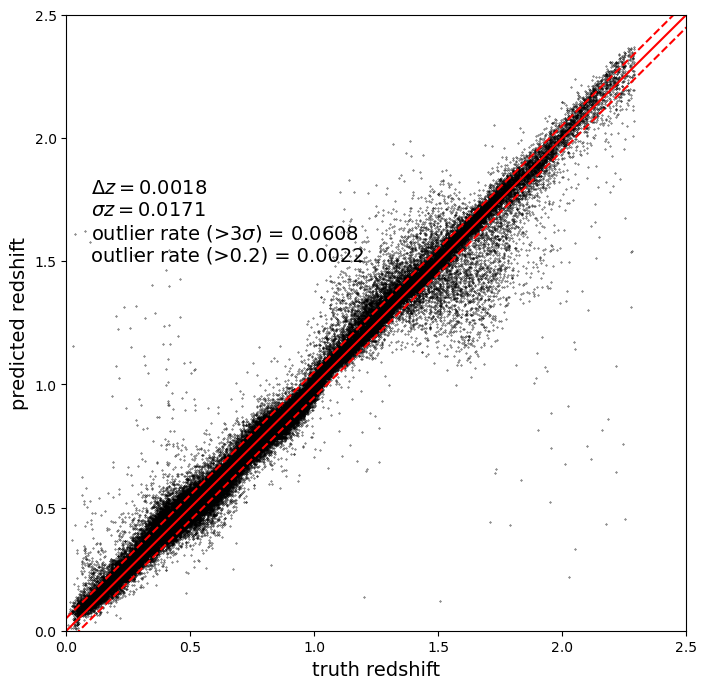

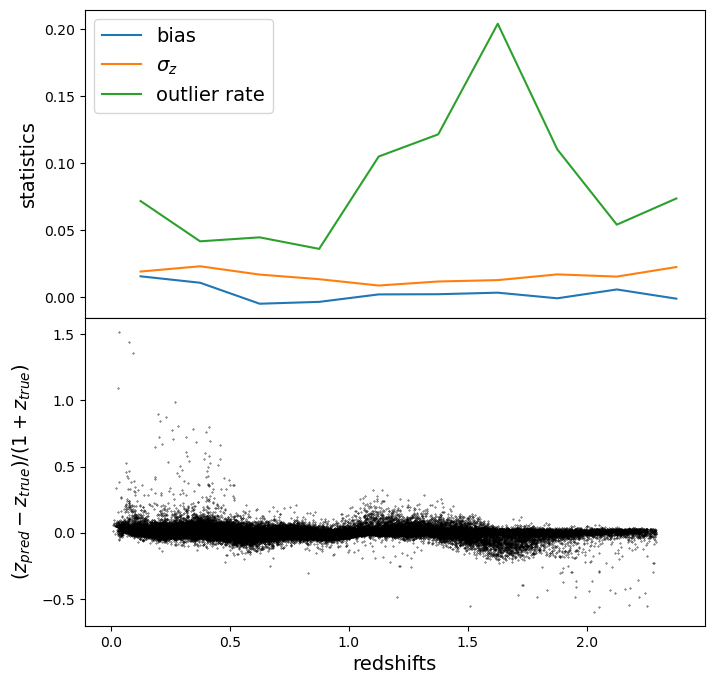

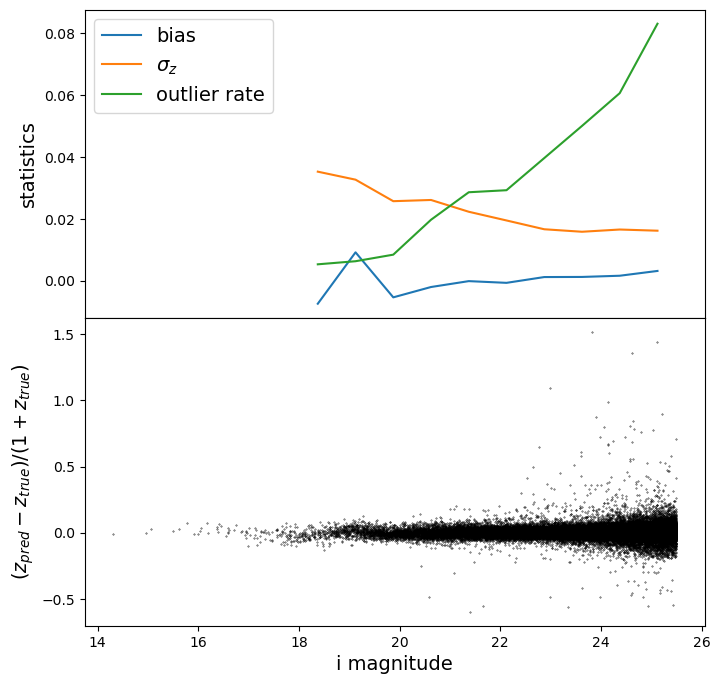

In [41]:
#training
plot_stats(stats4, redshift_stats4, imag_stats4, Y_test, Y_pred_test, redshift_bins, imag_bins, test_data['mag_i_lsst'])

Text(0, 0.5, 'predicted redshift')

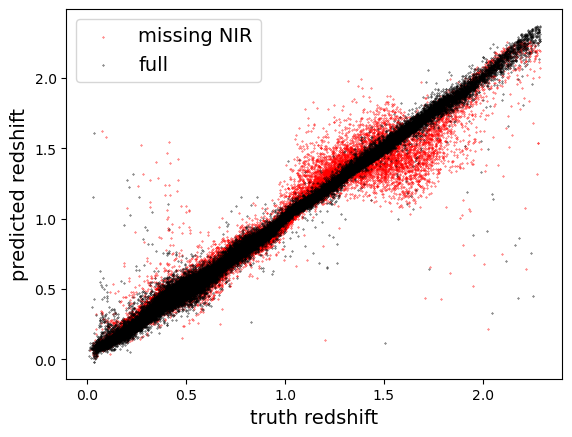

In [42]:
# split it into without missing and with missing:
ind_missing = np.sum(X_test_missing[:, 15:, 2], axis=1) == 0
plt.scatter(Y_test[ind_missing], Y_pred_test[ind_missing], color='r', s=0.1, label='missing NIR')
plt.scatter(Y_test[~ind_missing], Y_pred_test[~ind_missing], color='k', s=0.1, label='full')
plt.legend()
plt.xlabel("truth redshift")
plt.ylabel("predicted redshift")

# Missing NIR bands with augmented data

Add a fraction of the training data, remove the NIR bands

In [172]:
# here code up a CNN to with a 1D filter:
from tensorflow.keras import layers, models, callbacks

tf.keras.backend.clear_session()

def build_model(input_shape):
    model = models.Sequential([
        layers.Conv1D(32,  kernel_size=3, activation='relu',
                      padding='same', input_shape=input_shape),
        layers.MaxPooling1D(),
        layers.Conv1D(64,  kernel_size=3, activation='relu',
                      padding='same'),
        layers.MaxPooling1D(),
        layers.Conv1D(128, kernel_size=3, activation='relu',
                      padding='same'),
        layers.MaxPooling1D(),
        layers.Conv1D(256, kernel_size=3, activation='relu',
                      padding='same'),
        layers.MaxPooling1D(),
        layers.Conv1D(512, kernel_size=3, activation='relu',
                      padding='same'),
        #layers.Conv1D(512, kernel_size=3, activation='relu',
        #              padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1)
    ])
    return model

model = build_model(input_shape=(30, 3))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

# ── Callbacks ─────────────────────────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 30, 32)            320       
                                                                 
 max_pooling1d (MaxPooling1  (None, 15, 32)            0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 15, 64)            6208      
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 7, 64)             0         
 g1D)                                                            
                                                                 
 conv1d_2 (Conv1D)           (None, 7, 128)            24704     
                                                                 
 max_pooling1d_2 (MaxPoolin  (None, 3, 128)            0

In [175]:
# ── Train ─────────────────────────────────────────────────────────────────────
history = model.fit(
    X_train_missing_agumented, Y_train_missing_augmented,
    validation_data=(X_val_missing, Y_val_norm),
    #validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
452/452 [==============================] - 12s 23ms/step - loss: 0.4387 - mae: 0.4760 - val_loss: 0.2861 - val_mae: 0.4030 - lr: 0.0010
Epoch 2/100
452/452 [==============================] - 5s 10ms/step - loss: 0.1775 - mae: 0.2958 - val_loss: 0.1354 - val_mae: 0.2469 - lr: 0.0010
Epoch 3/100
452/452 [==============================] - 5s 11ms/step - loss: 0.1318 - mae: 0.2487 - val_loss: 0.1236 - val_mae: 0.2616 - lr: 0.0010
Epoch 4/100
452/452 [==============================] - 5s 10ms/step - loss: 0.1029 - mae: 0.2168 - val_loss: 0.0741 - val_mae: 0.1846 - lr: 0.0010
Epoch 5/100
452/452 [==============================] - 5s 10ms/step - loss: 0.0838 - mae: 0.1929 - val_loss: 0.1193 - val_mae: 0.2506 - lr: 0.0010
Epoch 6/100
452/452 [==============================] - 5s 12ms/step - loss: 0.0785 - mae: 0.1859 - val_loss: 0.0462 - val_mae: 0.1231 - lr: 0.0010
Epoch 7/100
452/452 [==============================] - 5s 12ms/step - loss: 0.0695 - mae: 0.1734 - val_loss: 0.0918 -

<Axes: xlabel='Epoch'>

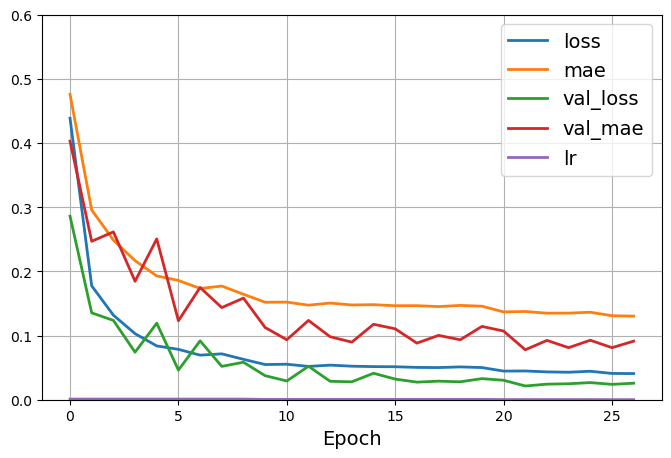

In [181]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5),
    linewidth=2,
    grid=True,
    xlabel='Epoch',
    ylim=(0,0.6),
)

In [182]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/cardinal/models/"
model.save(root + 'basic_CNN_missing_NIR_frac_0.3.model.5layers-augmented.keras')

# Save normalisation parameters alongside it
np.save(root + 'basic_CNN_missing_NIR_frac_0.3.norm_params.5layers-augmented.npy', {
    'Y_mean': Y_mean, 'Y_std': Y_std, 'X_max': max_mag,
})

In [184]:
Y_pred_norm = model.predict(X_train_missing)
Y_pred_train      = Y_pred_norm * Y_std + Y_mean

Y_pred_norm = model.predict(X_test_missing)
Y_pred_test      = Y_pred_norm * Y_std + Y_mean

3470/3470 [==============================] - 17s 5ms/step


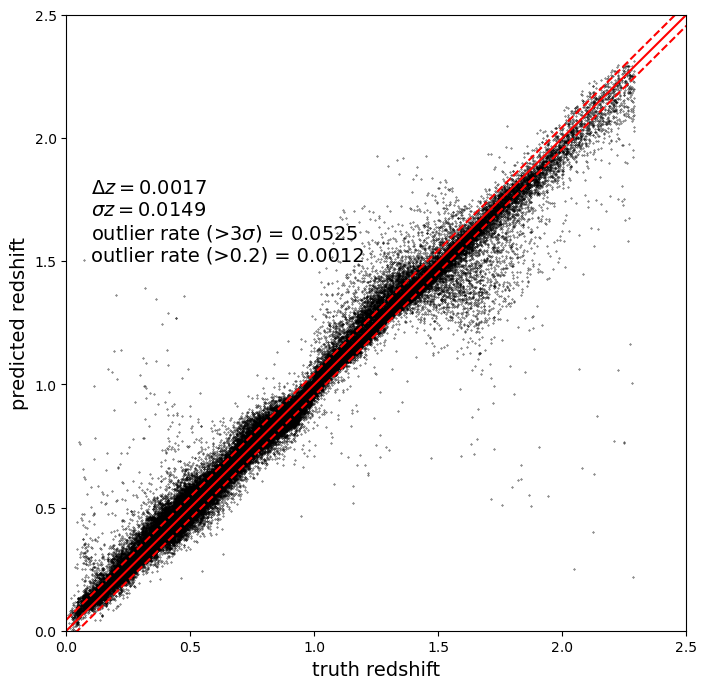

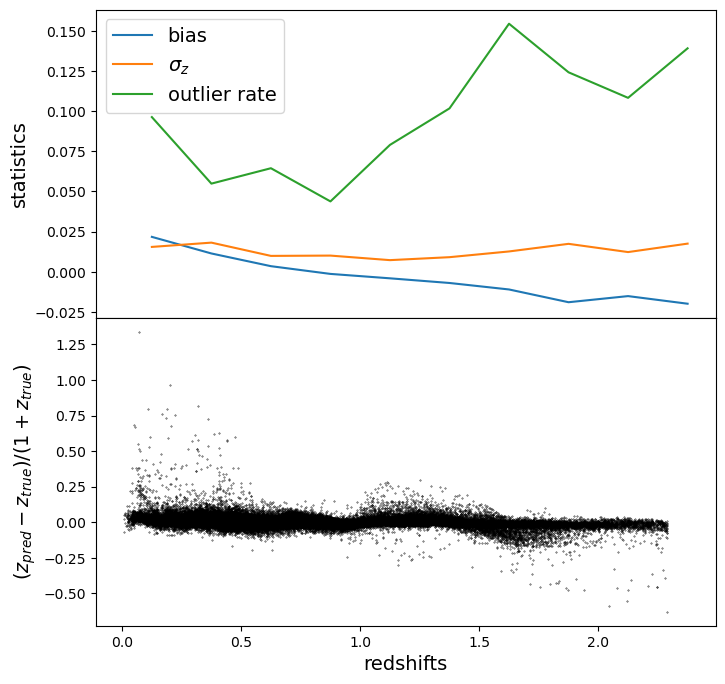

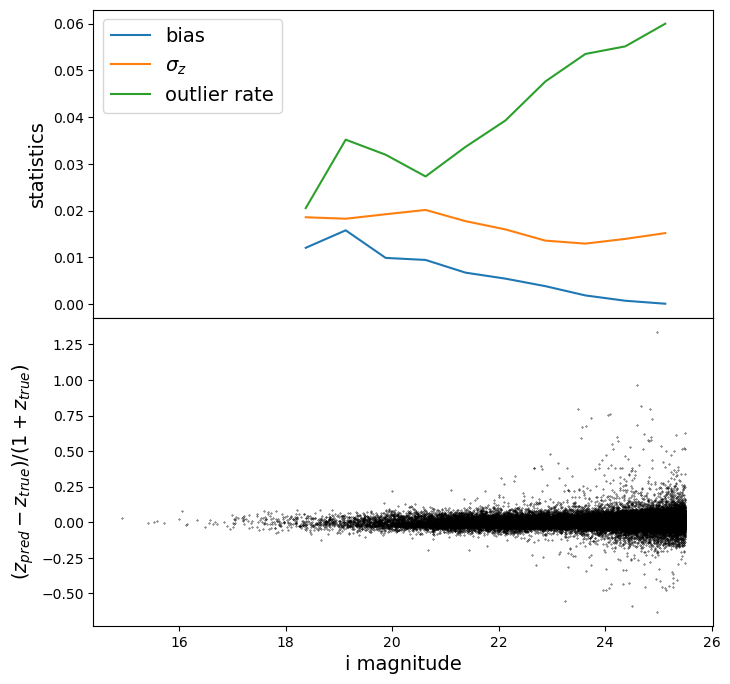

In [185]:
plot_stats(stats3, redshift_stats3, imag_stats3, Y_train, Y_pred_train, redshift_bins, imag_bins, training_data['mag_i_lsst'][idx_train])

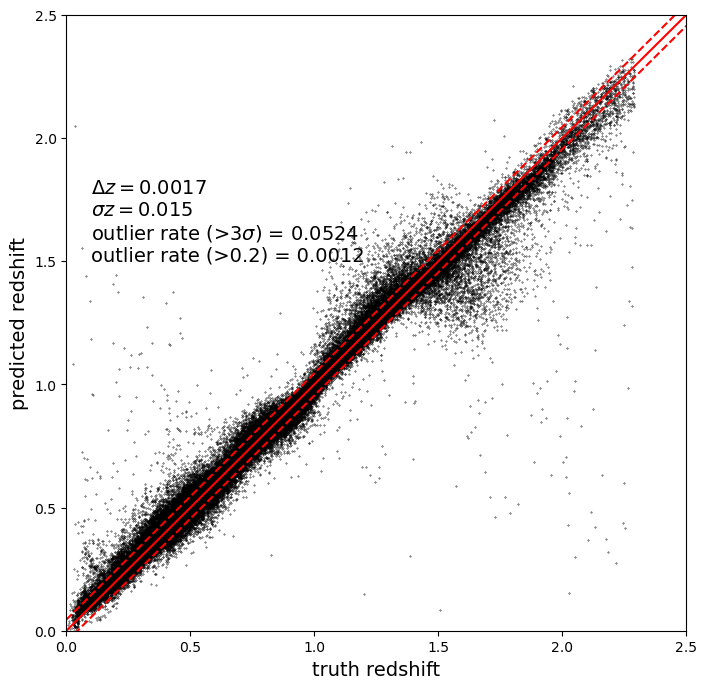

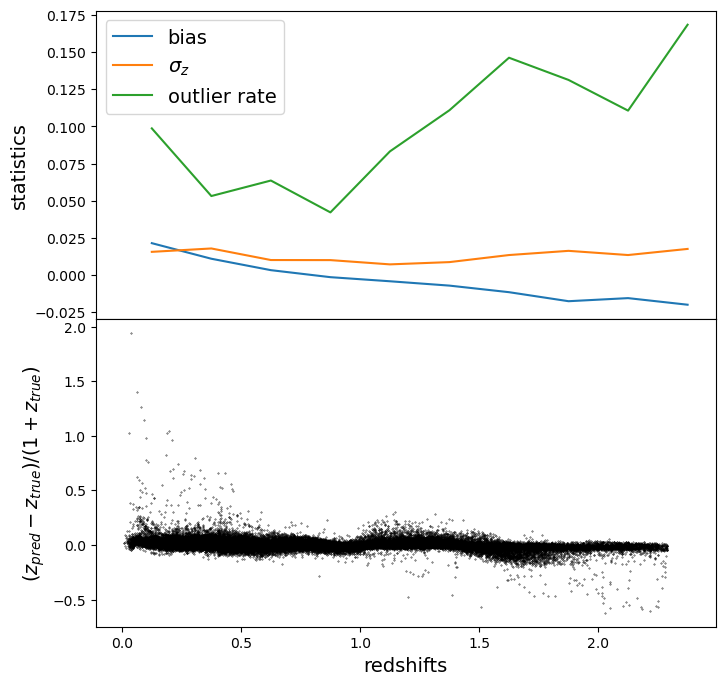

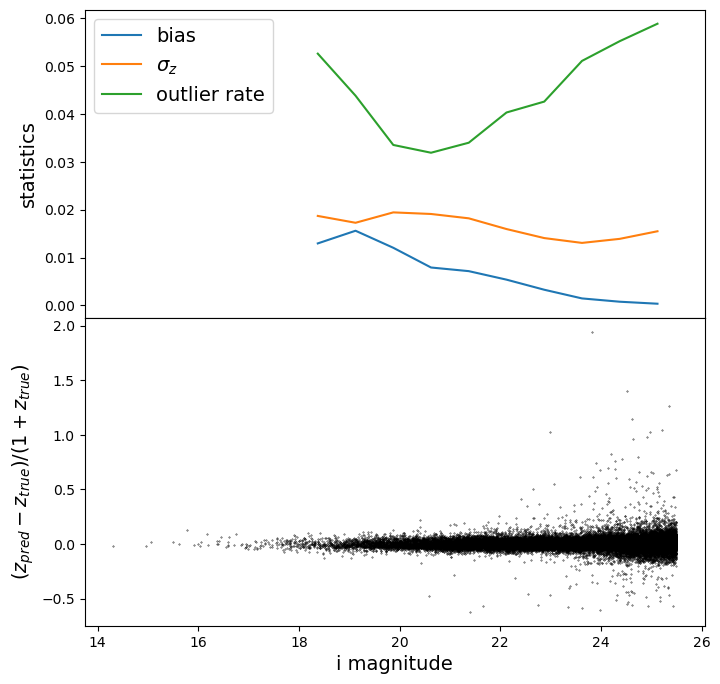

In [186]:
plot_stats(stats4, redshift_stats4, imag_stats4, Y_test, Y_pred_test, redshift_bins, imag_bins, test_data['mag_i_lsst'])

# Fractinal degradation in metrics: mean, var

In [82]:
from IPython.display import Markdown, display

In [83]:
md = stats_to_markdown(stats2, stats4, labels=("Mean", "Mean err", "Std", "Outlier rate", "Abs outlier rate"), skip_indices=(1,),
                      data_title=("ugrizyJH","30\% missing JH"))
display(Markdown(md))

| Statistic | ugrizyJH | 30\% missing JH | % change |
|---|---:|---:|---:|
| Mean | 0.00146 | -3.73e-05 | -103% |
| Std | 0.0102 | 0.0157 | 54.1% |
| Outlier rate | 0.0494 | 0.0573 | 15.9% |
| Abs outlier rate | 0.000477 | 0.00175 | 266% |

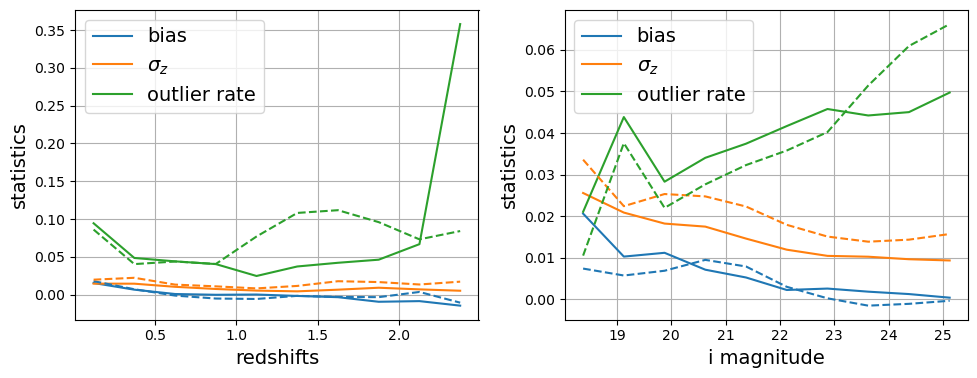

In [84]:
# now also compare changes in bins of redhsifts and imag:

compare_binned_stats(redshift_bins, imag_bins, redshift_stats2, imag_stats2, redshift_stats4, imag_stats4)